# Mealpy Timetabling

This notebook implements the railway scheduling problem using MEALPY metaheuristic algorithms.

## 0. Load Libraries

In [13]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import shutil
from pathlib import Path

from robin.supply.generator.entities import SupplyGenerator
from robin.supply.entities import Supply

from craft import RevenueSimulator
from craft import MealpyTimetabling

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Generate Supply

In [14]:
supply_config_path = Path("../configs/supply_generator/supply_data.yaml")
generator_config_path = Path("../configs/supply_generator/config.yaml")
generator_save_path = Path('../data/results/supply_mealpy.yaml')

Path('../data/results').mkdir(parents=True, exist_ok=True)

generator = SupplyGenerator.from_yaml(
    path_config_supply=supply_config_path,
    path_config_generator=generator_config_path
)

generator.generate(
    n_services=25,
    output_path=generator_save_path,
    seed=42,
    progress_bar=True,
    without_conflicts=False
)

print(f'Generated {len(generator.services)} services')

Generating services all: 100%|██████████| 25/25 [00:00<00:00, 500.20service/s]

Generated 25 services


## 2. Load Supply and Generate Revenue Behavior

In [15]:
supply = Supply.from_yaml(path=str(generator_save_path))
print(f'Loaded {len(supply.services)} services')

revenue_simulator = RevenueSimulator(supply=supply)
revenue_behavior = revenue_simulator.simulate_revenue(alpha=2/3)

print(f'Revenue behavior computed for {len(revenue_behavior)} services')

Loaded 25 services
Revenue behavior computed for 25 services


## 3. Initialize Timetabling Problem

In [16]:
timetabling = MealpyTimetabling(
    requested_services=supply.services,
    revenue_behavior=revenue_behavior,
    safe_headway=10,
    max_stop_time=10
)

print(f'Problem initialized with {timetabling.n_services} services')
print(f'Real variables: {len(timetabling.boundaries.real)}')

Problem initialized with 25 services
Real variables: 81


## 4. Define MEALPY Problem

In [17]:
from mealpy import FloatVar, IntegerVar
from mealpy import GA, DE, PSO, SCA

n_real = len(timetabling.boundaries.real)

bounds = []
for lb, ub in timetabling.boundaries.real:
    bounds.append(FloatVar(lb=lb, ub=ub))

print(f'Number of real variables: {n_real}')
print(f'Bounds: {bounds[:3]}...')

Number of real variables: 81
Bounds: [<mealpy.utils.space.FloatVar object at 0x136cce650>, <mealpy.utils.space.FloatVar object at 0x136d08090>, <mealpy.utils.space.FloatVar object at 0x136df7110>]...


## 5. Run GA Optimization

In [18]:
problem = {
    'obj_func': timetabling.objective_function,
    'bounds': bounds,
    'minmax': 'max',
    'verbose': True
}

model = GA.BaseGA(pop_size=20, n_iter=50, pc=0.9, pm=0.01, seed=42)

print("Starting GA optimization...")
model.solve(problem)

print(f'Best fitness: {model.g_best.target.fitness}')

2026/04/11 01:08:24 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: BaseGA(epoch=10000, pop_size=20, pc=0.9, pm=0.01)
2026/04/11 01:08:24 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: 504.56129975721035, Global best: 531.4150124958611, Runtime: 0.02391 seconds


Starting GA optimization...


2026/04/11 01:08:24 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: 534.6748396827986, Global best: 534.6748396827986, Runtime: 0.02703 seconds
2026/04/11 01:08:24 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: 510.86727796505335, Global best: 534.6748396827986, Runtime: 0.02350 seconds
2026/04/11 01:08:24 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: 509.8714895048092, Global best: 534.6748396827986, Runtime: 0.02562 seconds
2026/04/11 01:08:24 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: 541.2805456746778, Global best: 541.2805456746778, Runtime: 0.02440 seconds
2026/04/11 01:08:24 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 6, Current best: 547.6977365046281, Global best: 547.6977365046281, Runtime: 0.02497 seconds
2026/04/11 01:08:24 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 

Best fitness: 733.1479939029521


## 6. Results

In [19]:
best_position = model.g_best.solution
best_fitness = model.g_best.target.fitness

schedule = timetabling.get_heuristic_schedule()

print(f'Best fitness: {best_fitness}')
print(f'Scheduled services: {np.sum(schedule)}/{len(schedule)}')

Best fitness: 733.1479939029521
Scheduled services: 23/25


## 7. Update Supply with Solution

In [20]:
from craft import Solution

solution = Solution(real=best_position, discrete=schedule)
updated_services = timetabling.update_supply(str(generator_save_path), solution)

print(f'Updated supply contains {len(updated_services)} services')

Updated supply contains 23 services


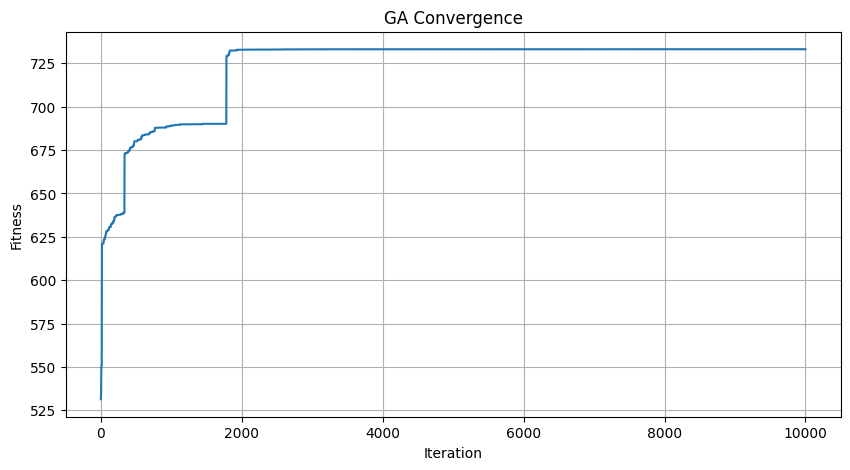

In [21]:
# Plot convergence
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot([data.target.fitness for data in model.history.list_global_best])
plt.xlabel('Iteration')
plt.ylabel('Fitness')
plt.title('GA Convergence')
plt.grid(True)
plt.show()

## 8. Try Other Algorithms

In [22]:
algorithms = {
    'DE': DE.Original(pop_size=20, n_iter=50, wf=0.5, cr=0.9, seed=42),
    'PSO': PSO.OriginalPSO(pop_size=20, n_iter=50, w=0.7, c1=1.5, c2=1.5, seed=42),
    'SCA': SCA.Original(pop_size=20, n_iter=50, seed=42)
}

results = {}

for name, algo in algorithms.items():
    print(f'Running {name}...')
    algo.solve(problem)
    results[name] = algo.g_best.target.fitness
    print(f'{name} best fitness: {results[name]}')

print('\n=== Results Summary ===')
for name, fitness in results.items():
    print(f'{name}: {fitness:.2f}')

AttributeError: module 'mealpy.evolutionary_based.DE' has no attribute 'Original'